#Приктическая работа №2
#Тема работы: "Майнинг данных и полиноминальных регрессий"

# В науке и разработке систем поддержки принятия решений (СППР)
# часто требуется моделировать зависимость на основве зависимости данных.
# Методология работы с данными определяется стандартом CRISP-DM (Cross-Industry Standart [rocess of Data Mining),
# что переводится как Межотраслевой Стандартный Процесс Майнинга Данных и объясняется как универсальный межотраслевой подход к анализу данных.
# Методология CRISP-DM показана на рис.1
#

#CRISP-DM является адаптаацией Agile-подхода к анализу данных

In [2]:
import pandas as pd

df = pd.read_csv('Ice_cream selling data.csv')
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


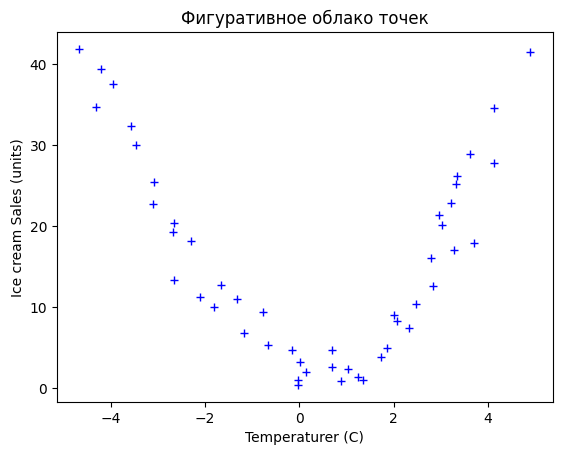

In [3]:
from  matplotlib import pyplot as plt

x = df['Temperature (°C)']
y = df['Ice Cream Sales (units)']

plt.plot(x,y, 'b+')
plt.xlabel('Temperaturer (C)')
plt.ylabel('Ice cream Sales (units)')
plt.title('Фигуративное облако точек')
plt.show()

"Понимание данных" в метеорологии CRISP-DM включает и сопровождается след. действиями:

<ol>
  <li>Визуализация данных<li>
  <li>Поиск "выбросов и аномалий (используется визуализация, анализ дисперсии, IsolationForests)"<li>
  <li>Предварительная обработка данных, включая масштабирование<li>
<ol>

In [ ]:
#Задача. Дан список произвольных чисел. Создать список квадратов этих чисел.
numbers = [1,20,3.14,10,0.34]
# squares = []
# for i in numbers:
#   squares.append(i**2)
# print(squares)

squares = [i**2 for i in numbers]
print(squares)

In [4]:
from sklearn.model_selection import train_test_split
# help(train_test_split)
X_train, X_test, y_train, y_test = train_test_split(x,y, shuffle=True, test_size=0.2, random_state = 42)

print('Количестро записей в наборе для обучение', len(X_train))
print('Количество записей в наборе для тестирования', len(X_test))
print(X_train)
print(type(X_train))



Количестро записей в наборе для обучение 39
Количество записей в наборе для тестирования 10
12   -2.111870
4    -3.578554
34    2.318591
8    -2.672461
3    -3.949661
6    -3.108440
40    3.211366
41    3.270044
46    4.130868
15   -1.326379
9    -2.652287
16   -1.173123
24    0.688781
33    2.075101
30    1.740000
0    -4.662263
43    3.335932
32    1.999310
5    -3.455712
29    1.359813
11   -2.288264
36    2.784836
1    -4.316559
21   -0.033895
2    -4.213985
37    2.831760
35    2.471946
23    0.149245
39    3.020874
10   -2.651498
22    0.008608
18   -0.673753
48    4.899032
20   -0.036156
7    -3.081303
42    3.316073
14   -1.660348
28    1.240712
38    2.959932
Name: Temperature (°C), dtype: float64
<class 'pandas.core.series.Series'>


[ 1.87145125 -0.70641926  2.76830583]
X[0] -4.662262677220208
f(X[0] 1 46.74097975085498
f(X[0]) 2 40.67916177961023


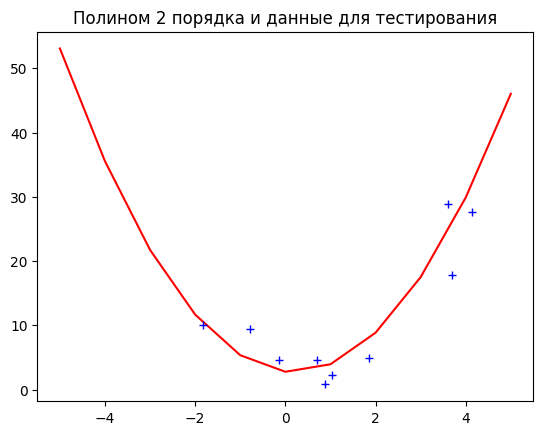

In [5]:
import numpy as np
info = """
  Для моделировнаия используем функцию polyfit
  из библиотеки numpy
  """

coeff = np.polyfit(X_train, y_train, deg=2)
print(coeff)

def model_n_order(coeff,x_in):
  out = []
  powers = list(range(0,len(coeff))) [::-1]
  for c,p in zip(coeff,powers):
    out.append(c*x_in**p)
    return sum(out)

f_x = lambda x: coeff[0]*x**2+coeff[1]*x + coeff[2]
X_model = list(range(-5,6))
y_model = [f_x(x) for x in X_model]

print('X[0]', x[0])
print('f(X[0] 1', f_x(x[0]))
print('f(X[0]) 2', model_n_order(coeff,x[0]))

plt.plot(X_model,y_model,'r-')
plt.plot(X_test,y_test,'b+')
plt.title('Полином 2 порядка и данные для тестирования')
plt.show()

In [7]:
print('Вычисление метрик качества обучения для полинома второго порядка')

coeff = np.polyfit(X_train, y_train, deg=2)
def model_norder(coeff,x):
  summands = [c*x**p for c,p in zip(coeff, list(range(0,len(coeff))))]
  return sum(summands)
#
ymodel = [model_norder(coeff,xi) for xi in X_test]
print("ymodel",ymodel)
print("y_test", y_test)

delta_m = [((ym-yt)**2)**0.5 for ym,yt in zip(ymodel, y_test)]
print("delta_m", delta_m)

MAE = sum(delta_m)/len(delta_m)
print('MAE',MAE)

delta_m_rel = [100*(((ym-yt)**2)**0.5)/yt for ym,yt in zip(ymodel, y_test)]
print("delta_m_rel = ",delta_m_rel)


Вычисление метрик качества обучения для полинома второго порядка
ymodel [np.float64(12.315417840339679), np.float64(37.23610462691154), np.float64(46.25099798311514), np.float64(35.41312743913617), np.float64(4.073302319026453), np.float64(4.051754464901451), np.float64(3.372425573869594), np.float64(2.713254544742409), np.float64(10.044366503962978), np.float64(2.0391402106744434)]
y_test 13    10.012868
45    17.843957
47    27.698383
44    28.912188
17     9.392969
27     2.313806
26     0.789974
25     4.625689
31     4.857988
19     4.673643
Name: Ice Cream Sales (units), dtype: float64
delta_m [np.float64(2.302549992010796), np.float64(19.39214810699802), np.float64(18.5526146349847), np.float64(6.500939509944224), np.float64(5.319666342082643), np.float64(1.7379481067279055), np.float64(2.58245192336182), np.float64(1.9124349127848501), np.float64(5.1863787028160635), np.float64(2.63450232987203)]
MAE 6.6121634561583065
delta_m_rel =  [np.float64(22.99590913301712), np.float64(1

In [ ]:
#A/B тестирования